In [31]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr
from scipy.stats import norm
import seaborn as sns

#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
    list_size = ['225','529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'
    list_size = ['228','550','961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"


Catania

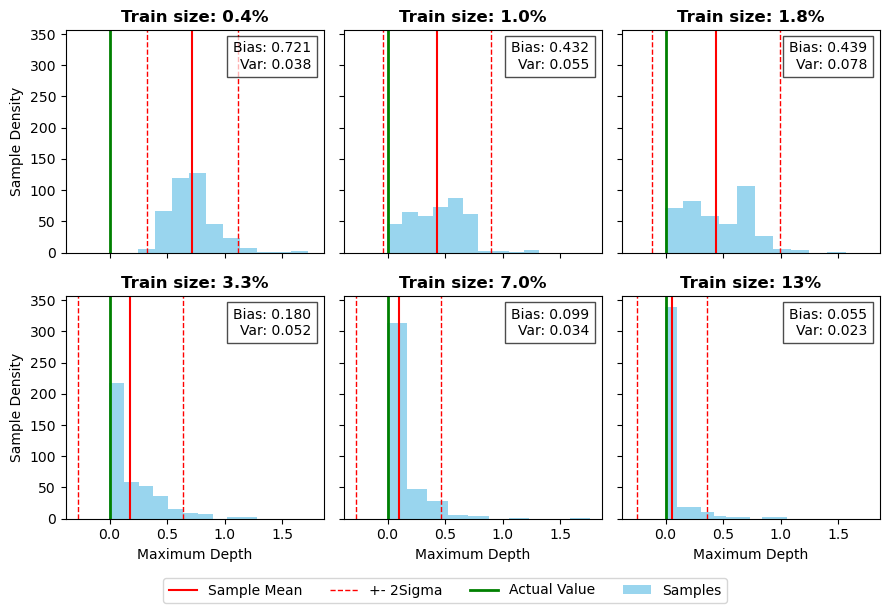

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs
test_set = 1
event_id = 3000
site = 5

# For subplot layout
ncols = 3
nrows = int(np.ceil(len(list_size) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharex=True, sharey=True)
axes = axes.flatten()
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

for idx, train_size in enumerate(list_size):
    # Load data
    sample = np.load(f'{MLDir}/model/{reg}/multifoldMC/out/mc_samples_trainsize{train_size}_testsize{test_set}_direct.npy')
    tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')

    # Extract sample and true/predicted
    pt_sc_sample = sample[:, event_id, site - 1]
    tpe_sc = tpe_table.iloc[[event_id]]
    true_val = tpe_sc[f'T{site}'].values[0]

    ax = axes[idx]

    # Mean, Median, Std
    mc_mean = np.mean(pt_sc_sample)
    mc_std = np.std(pt_sc_sample)
    mc_median = np.median(pt_sc_sample)
    
    # Bias and variance
    bias = np.abs(true_val - mc_mean)
    var = np.var(pt_sc_sample)

    # Plot indicators
    ax.axvline(mc_mean, color='r', label='Sample Mean')
    ax.axvline(mc_mean + 2*mc_std, color='r', linestyle='--', linewidth=1)
    ax.axvline(mc_mean - 2*mc_std, color='r', linestyle='--', linewidth=1,label='+- 2Sigma')
    ax.axvline(true_val, color='g', label='Actual Value', linewidth=2)
    ax.hist(pt_sc_sample, bins=10, density=False, alpha=0.85, color='skyblue', label='Samples')

    # Title & Text
    ax.set_title(f'Train size: {labels[idx]}', fontsize=12, fontweight='bold')
    ax.text(0.95, 0.95, f'Bias: {bias:.3f}\nVar: {var:.3f}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    if idx == 0 or idx == 3:
        ax.set_ylabel('Sample Density')
    if idx >= 3:
        ax.set_xlabel('Maximum Depth')
    # ax.legend(loc='upper left', fontsize=10)
    # ax.set_ylim(0, 12)

# Hide empty subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

# Legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.01), fontsize=10)

# plt.suptitle(f'Distribution of Ensemble Samples for a site with True Value = {true_val:.3f}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'samples_{reg}_site{site}.png', dpi=300, bbox_inches='tight')
plt.show()


/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:1904: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


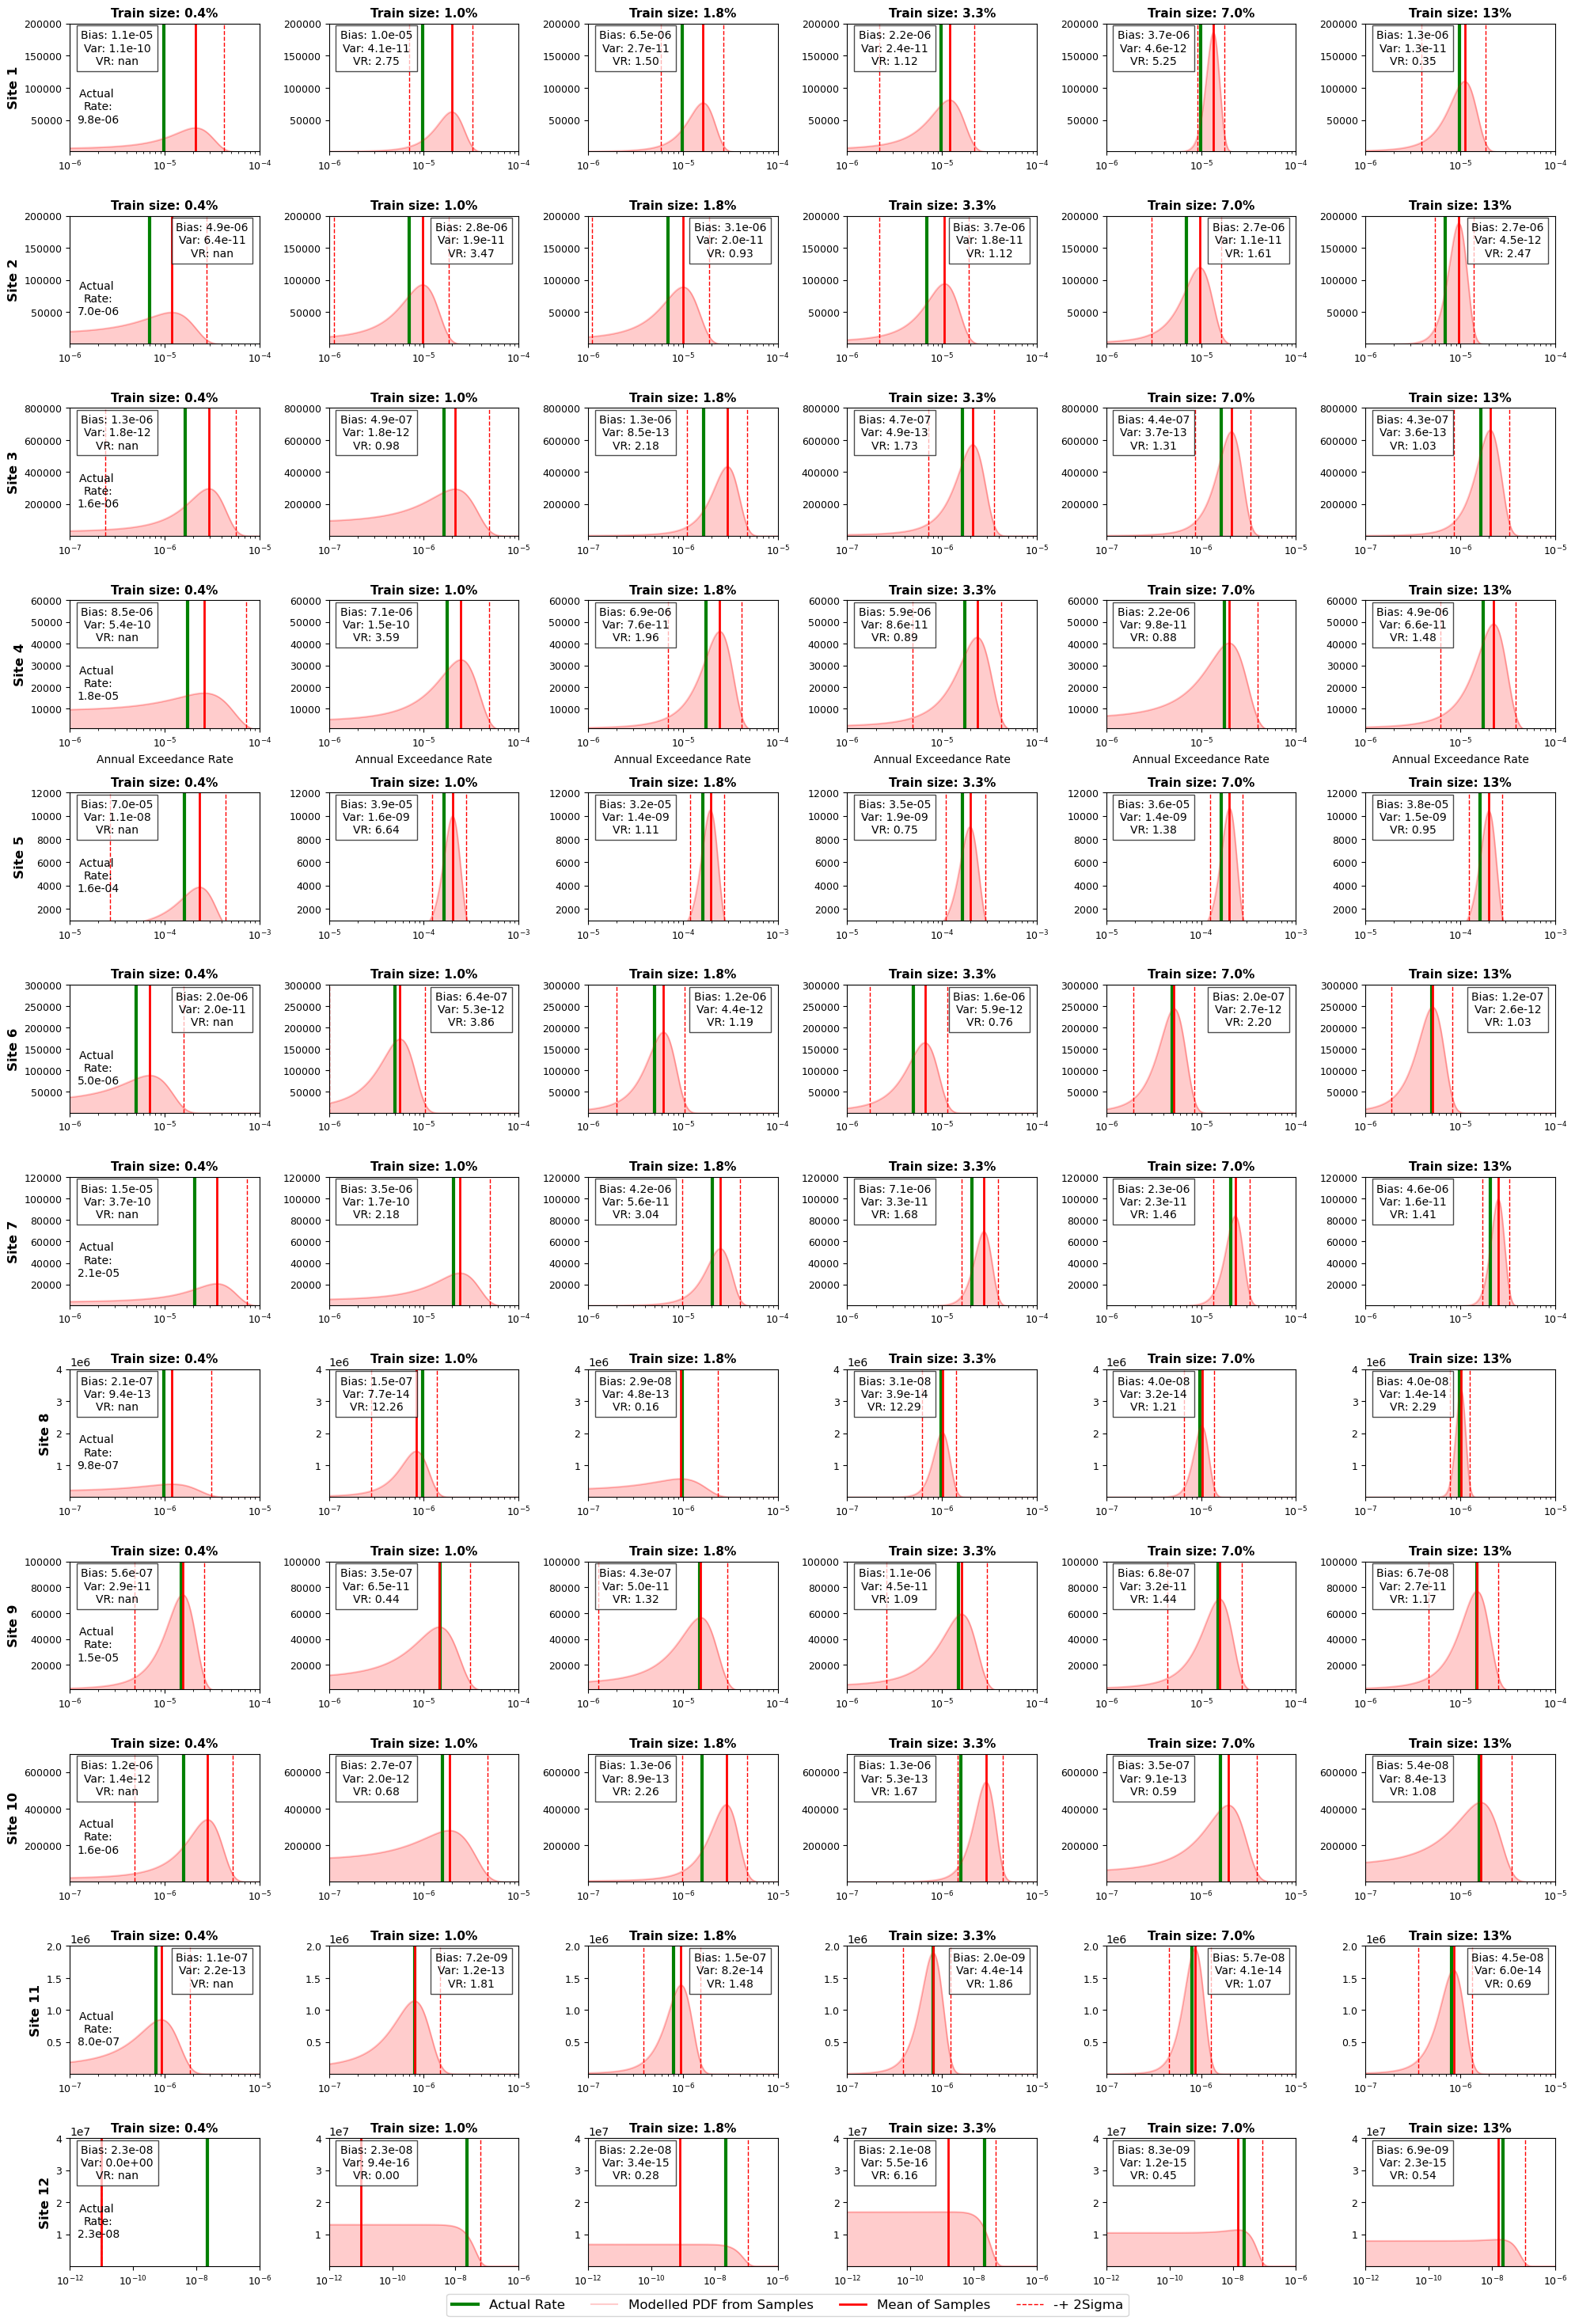

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Config
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

fig, ax = plt.subplots(12, 6, figsize=(20, 30), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for Site in range(1, 13):
    j = Site - 1
    Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]

    prev_var = None
    for i, train_size in enumerate(list_size):
        row = Table_rate[Table_rate['Train_size'] == int(train_size)]
        if row.empty:
            continue

        obs = row['True'].item()
        mu = row['Pred'].item()
        sigma = row['Sigma'].item() / 2  # from 2-sigma
        var = sigma ** 2
        VR = prev_var / var if prev_var is not None else np.nan
        prev_var = var

        # Plot distribution
        x = np.logspace(-13, -3, 50000)

        ax[j, i].axvline(obs, color='green', linestyle='-', label='Actual Rate',linewidth=3)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='r', label='Modelled PDF from Samples',alpha=0.2)
        ax[j, i].axvline(mu, color='r', linestyle='-', label='Mean of Samples',linewidth=2)
        ax[j, i].axvline(mu + 2 * sigma, color='r', linestyle='--', linewidth=1)
        ax[j, i].axvline(mu - 2 * sigma, color='r', linestyle='--', linewidth=1, label='-+ 2Sigma')
        ax[j, i].fill_between(x, norm.pdf(x, mu, sigma), color='r', alpha=0.2)

        # For first column, put label on left; for third row, put label on right
        if i == 0 :
            ax[j, i].text(0.15, 0.35, f'Actual \nRate:\n{obs:.1e}', transform=ax[j, i].transAxes, ha='center', va='center', fontsize=10)
        

        # Annotate bias, var, VR
        bias = np.abs(obs - mu)
        if j == 1 or j==10 or j==5:
            ax[j, i].text(0.75, 0.95, f'Bias: {bias:.1e}\nVar: {var:.1e}\nVR: {VR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        else:
            ax[j, i].text(0.25, 0.95, f'Bias: {bias:.1e}\nVar: {var:.1e}\nVR: {VR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

        # Aesthetics
        ax[j, i].set_xscale('log')
        ax[j, i].set_title(f"Train size: {labels[i]}", fontsize=11,fontweight='bold')
        ax[j, i].tick_params(labelsize=9)

        # Axis labels
        if i == 0:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=12,fontweight='bold')
        if j == 3:
            ax[j, i].set_xlabel("Annual Exceedance Rate", fontsize=10)
        
        # Set x and y limits
        ax[j, i].set_xlim(1e-6, 1e-4)
        ax[j, i].set_ylim(1000, 2e5)

        if j == 2:
            ax[j, i].set_ylim(1000, 8e5)
            ax[j, i].set_xlim(1e-7, 1e-5)
        elif j == 3 :
            ax[j, i].set_ylim(1000, 6e4)
        elif j == 4:
            ax[j, i].set_xlim(1e-5, 1e-3)
            ax[j, i].set_ylim(1000, 1.2e4)
        elif j==5:
            ax[j, i].set_ylim(1000, 3e5)
        elif j==6:
            ax[j, i].set_xlim(1e-6, 1e-4)
            ax[j, i].set_ylim(1000, 1.2e5)
        elif j==7:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 4e6)
        elif j == 8:
            ax[j, i].set_ylim(1000, 1e5)
        elif j == 9:
            ax[j, i].set_ylim(1000, 7e5)
            ax[j, i].set_xlim(1e-7, 1e-5)
        elif j == 10:
            ax[j, i].set_ylim(1000, 2e6)
            ax[j, i].set_xlim(1e-7, 1e-5)
        elif j == 11:
            ax[j, i].set_ylim(1000, 4e7)
            ax[j, i].set_xlim(1e-12, 1e-6)
            

# Legend once
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'pdf_allsites_{reg}_250cm.png', dpi=300, bbox_inches='tight')
plt.show()


Siracusa

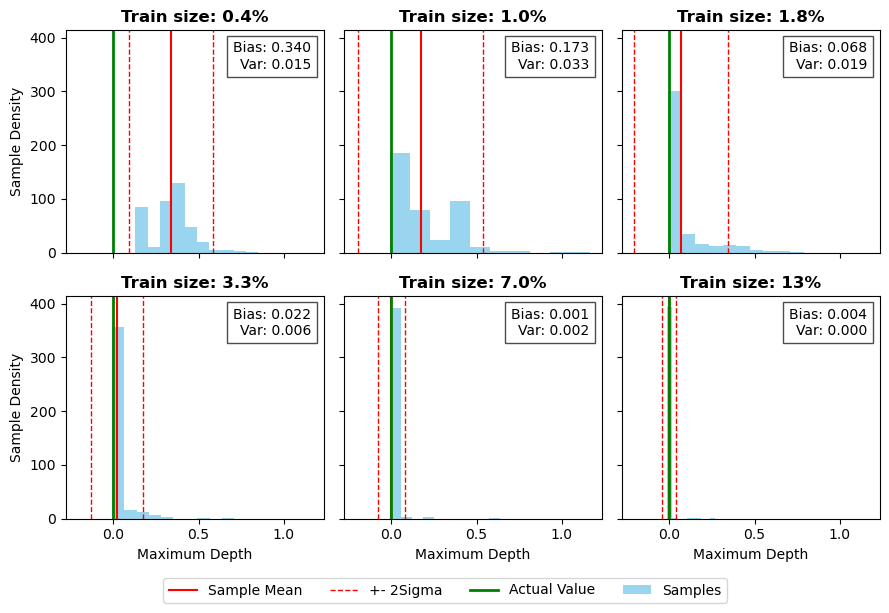

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs
test_set = 1
event_id = 4000
site = 2

# For subplot layout
ncols = 3
nrows = int(np.ceil(len(list_size) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharex=True, sharey=True)
axes = axes.flatten()
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

for idx, train_size in enumerate(list_size):
    # Load data
    sample = np.load(f'{MLDir}/model/{reg}/multifoldMC/out/mc_samples_trainsize{train_size}_testsize{test_set}_direct.npy')
    tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')

    # Extract sample and true/predicted
    pt_sc_sample = sample[:, event_id, site - 1]
    tpe_sc = tpe_table.iloc[[event_id]]
    true_val = tpe_sc[f'T{site}'].values[0]

    ax = axes[idx]


    # Mean, Median, Std
    mc_mean = np.mean(pt_sc_sample)
    mc_std = np.std(pt_sc_sample)
    mc_median = np.median(pt_sc_sample)
    
    # Bias and variance
    bias = np.abs(true_val - mc_mean)
    var = np.var(pt_sc_sample)

    # Plot indicators
    ax.axvline(mc_mean, color='r', label='Sample Mean')
    ax.axvline(mc_mean + 2*mc_std, color='r', linestyle='--', linewidth=1)
    ax.axvline(mc_mean - 2*mc_std, color='r', linestyle='--', linewidth=1,label='+- 2Sigma')
    ax.axvline(true_val, color='g', label='Actual Value', linewidth=2)
    ax.hist(pt_sc_sample, bins=10, density=False, alpha=0.85, color='skyblue', label='Samples')

    # Title & Text
    ax.set_title(f'Train size: {labels[idx]}', fontsize=12, fontweight='bold')
    ax.text(0.95, 0.95, f'Bias: {bias:.3f}\nVar: {var:.3f}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    if idx == 0 or idx == 3:
        ax.set_ylabel('Sample Density')
    if idx >= 3:
        ax.set_xlabel('Maximum Depth')
    # ax.legend(loc='upper left', fontsize=10)
    # ax.set_ylim(0, 12)

# Hide empty subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

# Legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.01), fontsize=10)

# plt.suptitle(f'Distribution of Ensemble Samples for a site with True Value = {true_val:.3f}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'samples_{reg}_site{site}.png', dpi=300, bbox_inches='tight')
plt.show()


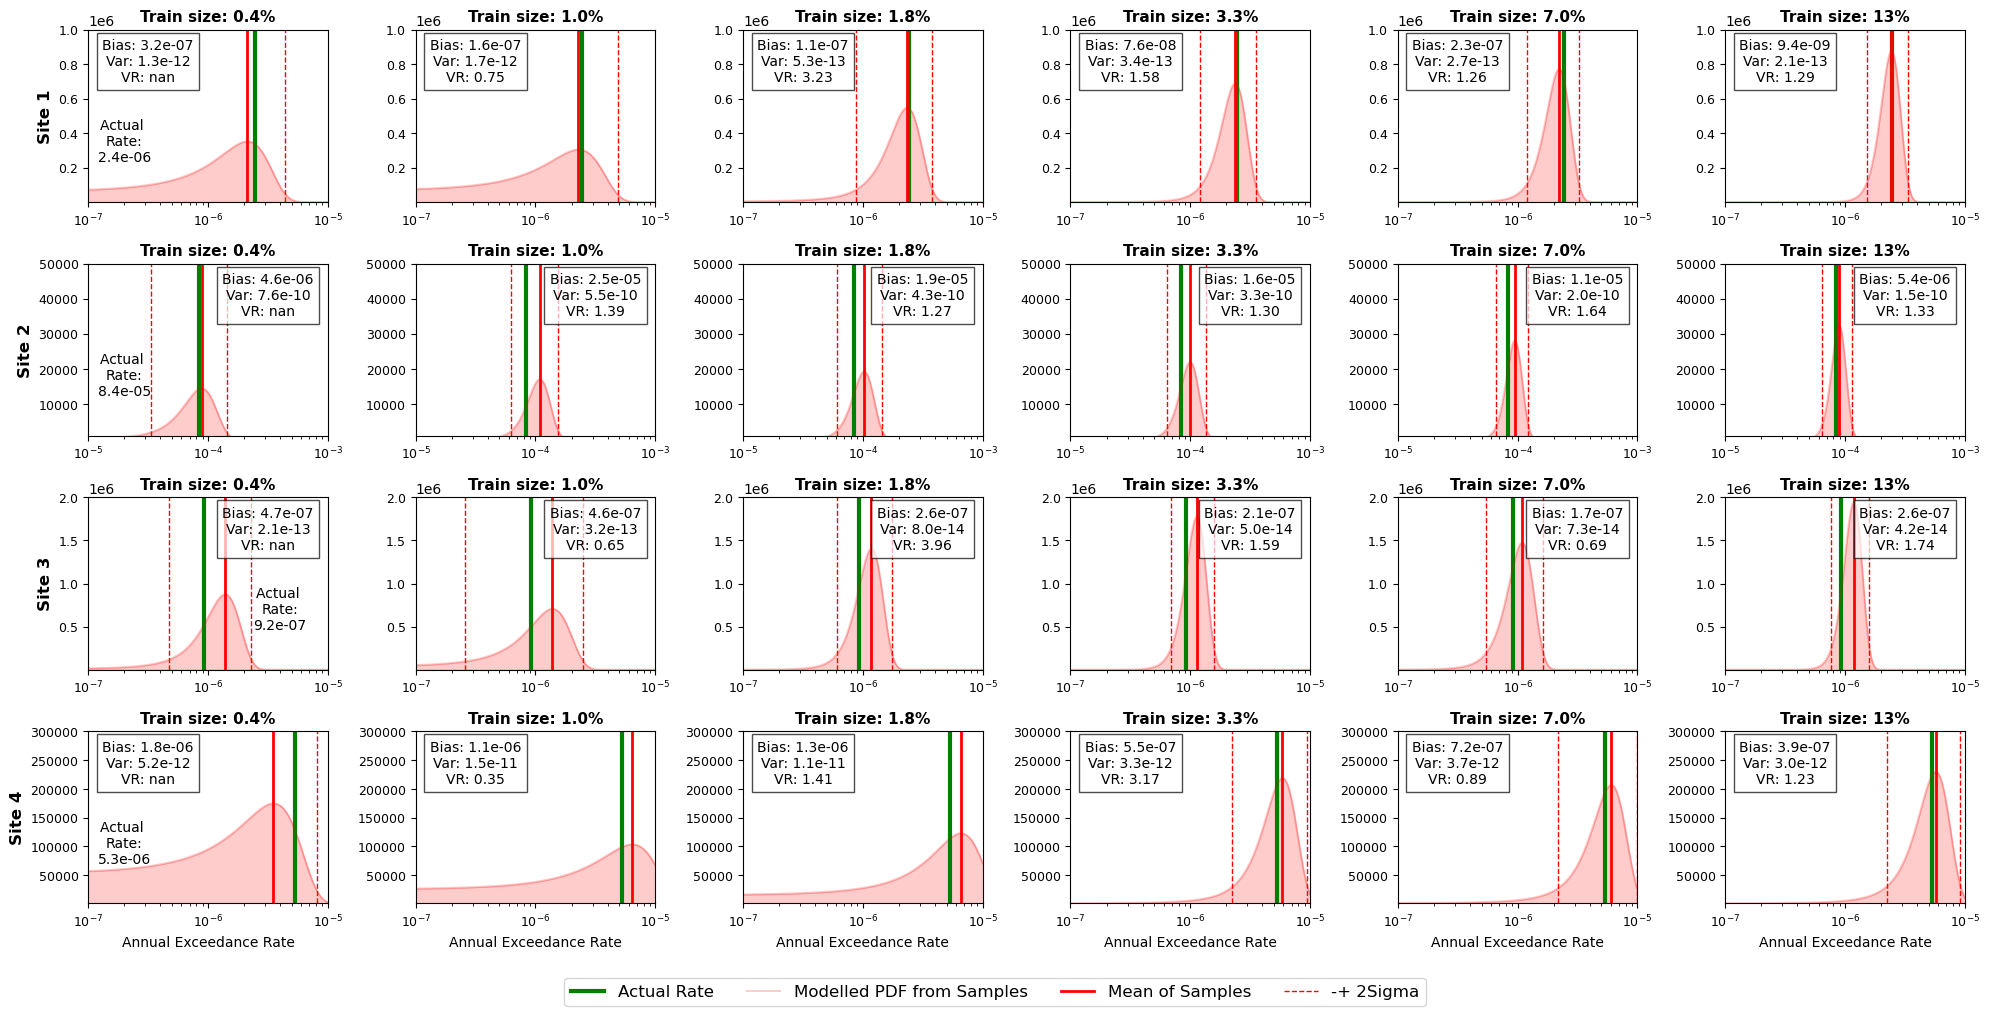

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Config
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

fig, ax = plt.subplots(4, 6, figsize=(20, 10), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for Site in range(1, 5):
    j = Site - 1
    Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]

    prev_var = None
    for i, train_size in enumerate(list_size):
        row = Table_rate[Table_rate['Train_size'] == int(train_size)]
        if row.empty:
            continue

        obs = row['True'].item()
        mu = row['Pred'].item()
        sigma = row['Sigma'].item() / 2  # from 2-sigma
        var = sigma ** 2
        VR = prev_var / var if prev_var is not None else np.nan
        prev_var = var

        # Plot distribution
        x = np.logspace(-8, -3, 10000)

        ax[j, i].axvline(obs, color='green', linestyle='-', label='Actual Rate',linewidth=3)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='r', label='Modelled PDF from Samples',alpha=0.2)
        ax[j, i].axvline(mu, color='r', linestyle='-', label='Mean of Samples',linewidth=2)
        ax[j, i].axvline(mu + 2 * sigma, color='r', linestyle='--', linewidth=1)
        ax[j, i].axvline(mu - 2 * sigma, color='r', linestyle='--', linewidth=1, label='-+ 2Sigma')
        ax[j, i].fill_between(x, norm.pdf(x, mu, sigma), color='r', alpha=0.2)

        # For first column, put label on left; for third row, put label on right
        if i == 0 and j != 2:
            ax[j, i].text(0.15, 0.35, f'Actual \nRate:\n{obs:.1e}', transform=ax[j, i].transAxes, ha='center', va='center', fontsize=10)
        elif i == 0 and j == 2:
            ax[j, i].text(0.80, 0.35, f'Actual \nRate:\n{obs:.1e}', transform=ax[j, i].transAxes, ha='center', va='center', fontsize=10)

        # Annotate bias, var, VR
        bias = np.abs(obs - mu)
        if j ==1 or j == 2:
            ax[j, i].text(0.75, 0.95, f'Bias: {bias:.1e}\nVar: {var:.1e}\nVR: {VR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        else:
            ax[j, i].text(0.25, 0.95, f'Bias: {bias:.1e}\nVar: {var:.1e}\nVR: {VR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

        # Aesthetics
        ax[j, i].set_xscale('log')
        ax[j, i].set_title(f"Train size: {labels[i]}", fontsize=11,fontweight='bold')
        ax[j, i].tick_params(labelsize=9)

        # Axis labels
        if i == 0:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=12,fontweight='bold')
        if j == 3:
            ax[j, i].set_xlabel("Annual Exceedance Rate", fontsize=10)
        
        # Set x and y limits
        if j ==0:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 1e6)
        elif j == 1:
            ax[j, i].set_xlim(1e-5, 1e-3)
            ax[j, i].set_ylim(1000, 5e4)
        if j == 2:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 2e6)
        elif j == 3 :
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 3e5)

# Legend once
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'pdf_allsites_{reg}_250cm.png', dpi=300, bbox_inches='tight')
plt.show()
